Effective Channel = (809.9870959313034+5.550247761387794e-15j)
Channel Gain = 656079.0955752266
SNR = 0 dB  BER = 0.000000
SNR = 2 dB  BER = 0.000000
SNR = 4 dB  BER = 0.000000
SNR = 6 dB  BER = 0.000000
SNR = 8 dB  BER = 0.000000
SNR = 10 dB  BER = 0.000000
SNR = 12 dB  BER = 0.000000
SNR = 14 dB  BER = 0.000000
SNR = 16 dB  BER = 0.000000
SNR = 18 dB  BER = 0.000000
SNR = 20 dB  BER = 0.000000


C:\Users\arnav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


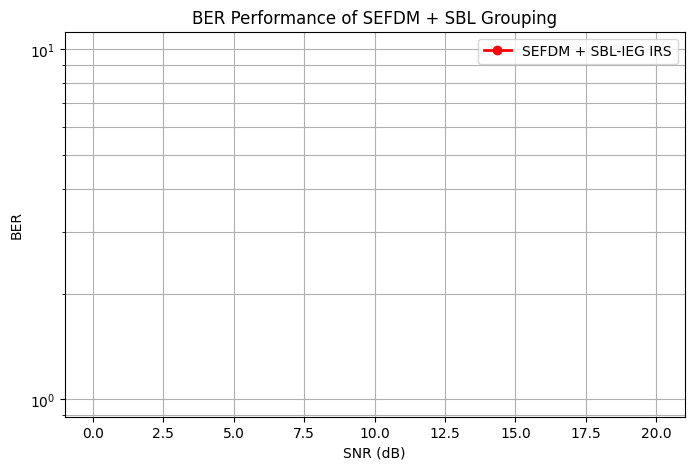

In [ ]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.channel import *
from src.grouping import *
from src.sefdm import *

import numpy as np
import matplotlib.pyplot as plt

# =====================================
# System Parameters
# =====================================

N = 64
M = 1000
Q = 250

alpha = 0.85

SNR_dB = np.arange(0, 22, 2)

num_blocks = 1000

BER = []

# =====================================
# Generate Channels
# =====================================

h_BI, h_IU = generate_channels(M)

cascaded = h_BI * h_IU

# =====================================
# SBL Grouping
# =====================================

groups = sbl_grouping(
    cascaded,
    Q=Q
)

# =====================================
# Effective Channel
# =====================================

h_eff = grouped_channel(
    h_BI,
    h_IU,
    groups
)
h_eff = h_eff / (len(h_BI) * (np.pi/4))

print("Effective Channel =", h_eff)
print("Channel Gain =", abs(h_eff)**2)

# =====================================
# SEFDM Matrix
# =====================================

F_SEFDM = generate_sefdm_matrix(
    N,
    alpha
)

# =====================================
# BER Simulation
# =====================================

for snr_db in SNR_dB:

    noise_var = 10**(-snr_db/10)

    total_errors = 0
    total_bits = 0

    for _ in range(num_blocks):

        bits = np.random.randint(
            0,
            2,
            N
        )

        s = 1 - 2 * bits

        # SEFDM Modulation

        x = F_SEFDM @ s

        # Channel + Noise

        noise = np.sqrt(noise_var / 2) * (
            np.random.randn(N)
            + 1j * np.random.randn(N)
        )

        y = h_eff * x + noise

        # MMSE Detection

        s_est = mmse_detector(
            y,
            F_SEFDM,
            h_eff,
            noise_var
        )

        bits_est = (
            np.real(s_est) < 0
        ).astype(int)

        total_errors += np.sum(
            bits != bits_est
        )

        total_bits += N

    ber = total_errors / total_bits

    BER.append(ber)

    print(
        f"SNR = {snr_db} dB  BER = {ber:.6f}"
    )

# =====================================
# Plot
# =====================================

plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    BER,
    'ro-',
    linewidth=2,
    label='SEFDM + SBL-IEG IRS'
)

plt.grid(True, which='both')

plt.xlabel("SNR (dB)")
plt.ylabel("BER")

plt.title(
    "BER Performance of SEFDM + SBL Grouping"
)

plt.legend()

plt.show()